In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")
import pandas as pd

from lib.loading import extract_all_set_collection
from lib.loading_labels import extract_all_data_types_collection
from lib.build_pairs import build_pairs  
from lib.extract_apk_permissions_dicts import extract_apk_permissions_dicts
from lib.extract_false_positives import extract_false_positives
from lib.calculate_micro_macro_samples import calculate_micro_macro_samples
from lib.calculate_per_label_f1 import calculate_per_label_f1
from lib.calculate_per_datatype_f1 import calculate_per_datatype_f1
from lib.count_fp_permissions import count_fp_permissions
from lib.count_apk_permissions import count_apk_permissions
from lib.plot_permission_counts_fp import plot_permission_counts_fp
from lib.plot_permission_counts import plot_permission_counts
from lib.plot_micro_macro_samples import plot_micro_macro_samples
from lib.plot_all_micro_macro_samples import plot_all_micro_macro_samples
from lib.plot_scatter_precision_recall import plot_scatter_precision_recall
from lib.plot_precision_recall_by_support_data_types import plot_precision_recall_by_support_data_types
from lib.plot_samples_comparison import plot_samples_comparison

In [2]:
runs = extract_all_set_collection("../data/testset_results_15_runs")
print(f"{len(runs)} Runs loaded")

15 Runs loaded


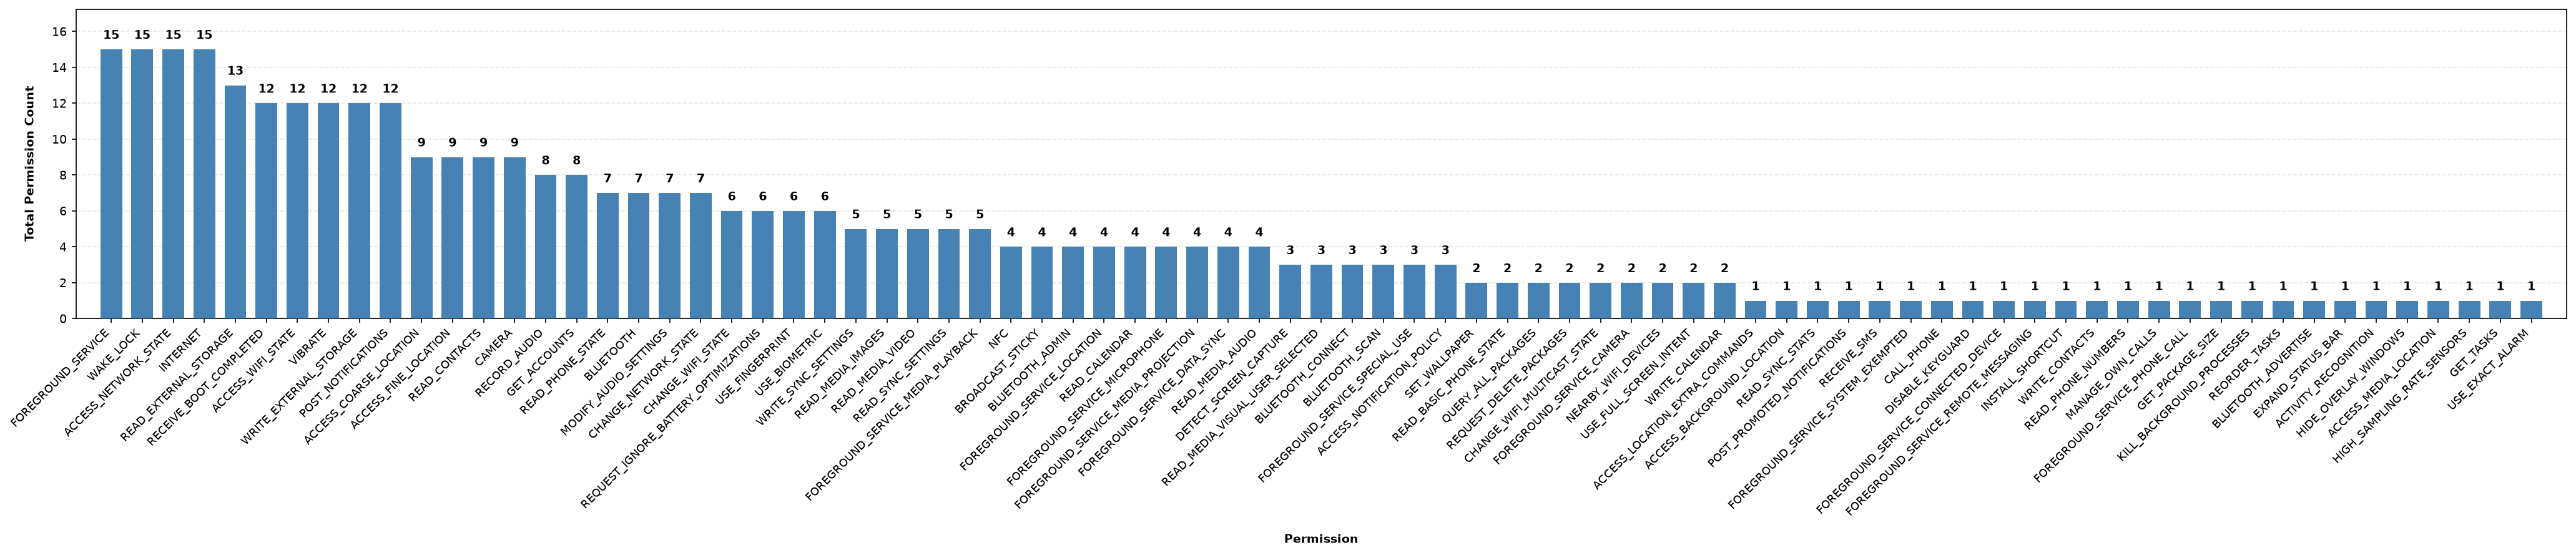

In [3]:
# extract apk permissions of all runs and count them, then plot the counts
apk_dicts = extract_apk_permissions_dicts(runs)
permission_counts = count_apk_permissions(apk_dicts)
plot_permission_counts(permission_counts, output_dir="../figures/figures_testset_15_runs")

In [4]:
pair_keys = [
    ("permissions_set_1", "inferred_permissions"),
    ("permissions_set_2", "inferred_permissions"),
    ("apk_permissions", "inferred_permissions"),
    ("apk_permissions", "permissions_set_1"),
    ("apk_permissions", "permissions_set_2"),
]

rows = []
for truth_key, pred_key in pair_keys:
    comps = build_pairs(runs, truth_key, pred_key)
    rows.append(calculate_micro_macro_samples(comps, truth_key, pred_key))

results_df = pd.DataFrame(rows)
results_df

,compare,label_gt_pred,precision_micro,recall_micro,f1_micro,precision_macro,recall_macro,f1_macro,precision_samples,recall_samples,f1_samples
0,set1_pipeline,Set 1 / Pipeline,0.476562,0.859155,0.613065,0.330039,0.393082,0.348843,0.501808,0.901481,0.620763
1,set2_pipeline,Set 2 / Pipeline,0.781250,0.425532,0.550964,0.431693,0.320624,0.346327,0.837385,0.459673,0.555099
2,apk_pipeline,APK / Pipeline,0.750000,0.266667,0.393443,0.353986,0.201893,0.234060,0.809033,0.309892,0.413870
3,apk_set1,APK / Set 1,0.816901,0.161111,0.269142,0.229152,0.132492,0.156539,0.875000,0.182355,0.285884
4,apk_set2,APK / Set 2,0.863830,0.563889,0.682353,0.594885,0.478091,0.503790,0.862379,0.602729,0.688806


In [5]:
#plot_micro_macro_samples(rows, "set1_pipeline", "../figures/figures_testset_15_runs")

In [6]:
#plot_micro_macro_samples(rows, "set2_pipeline", "../figures/figures_testset_15_runs")

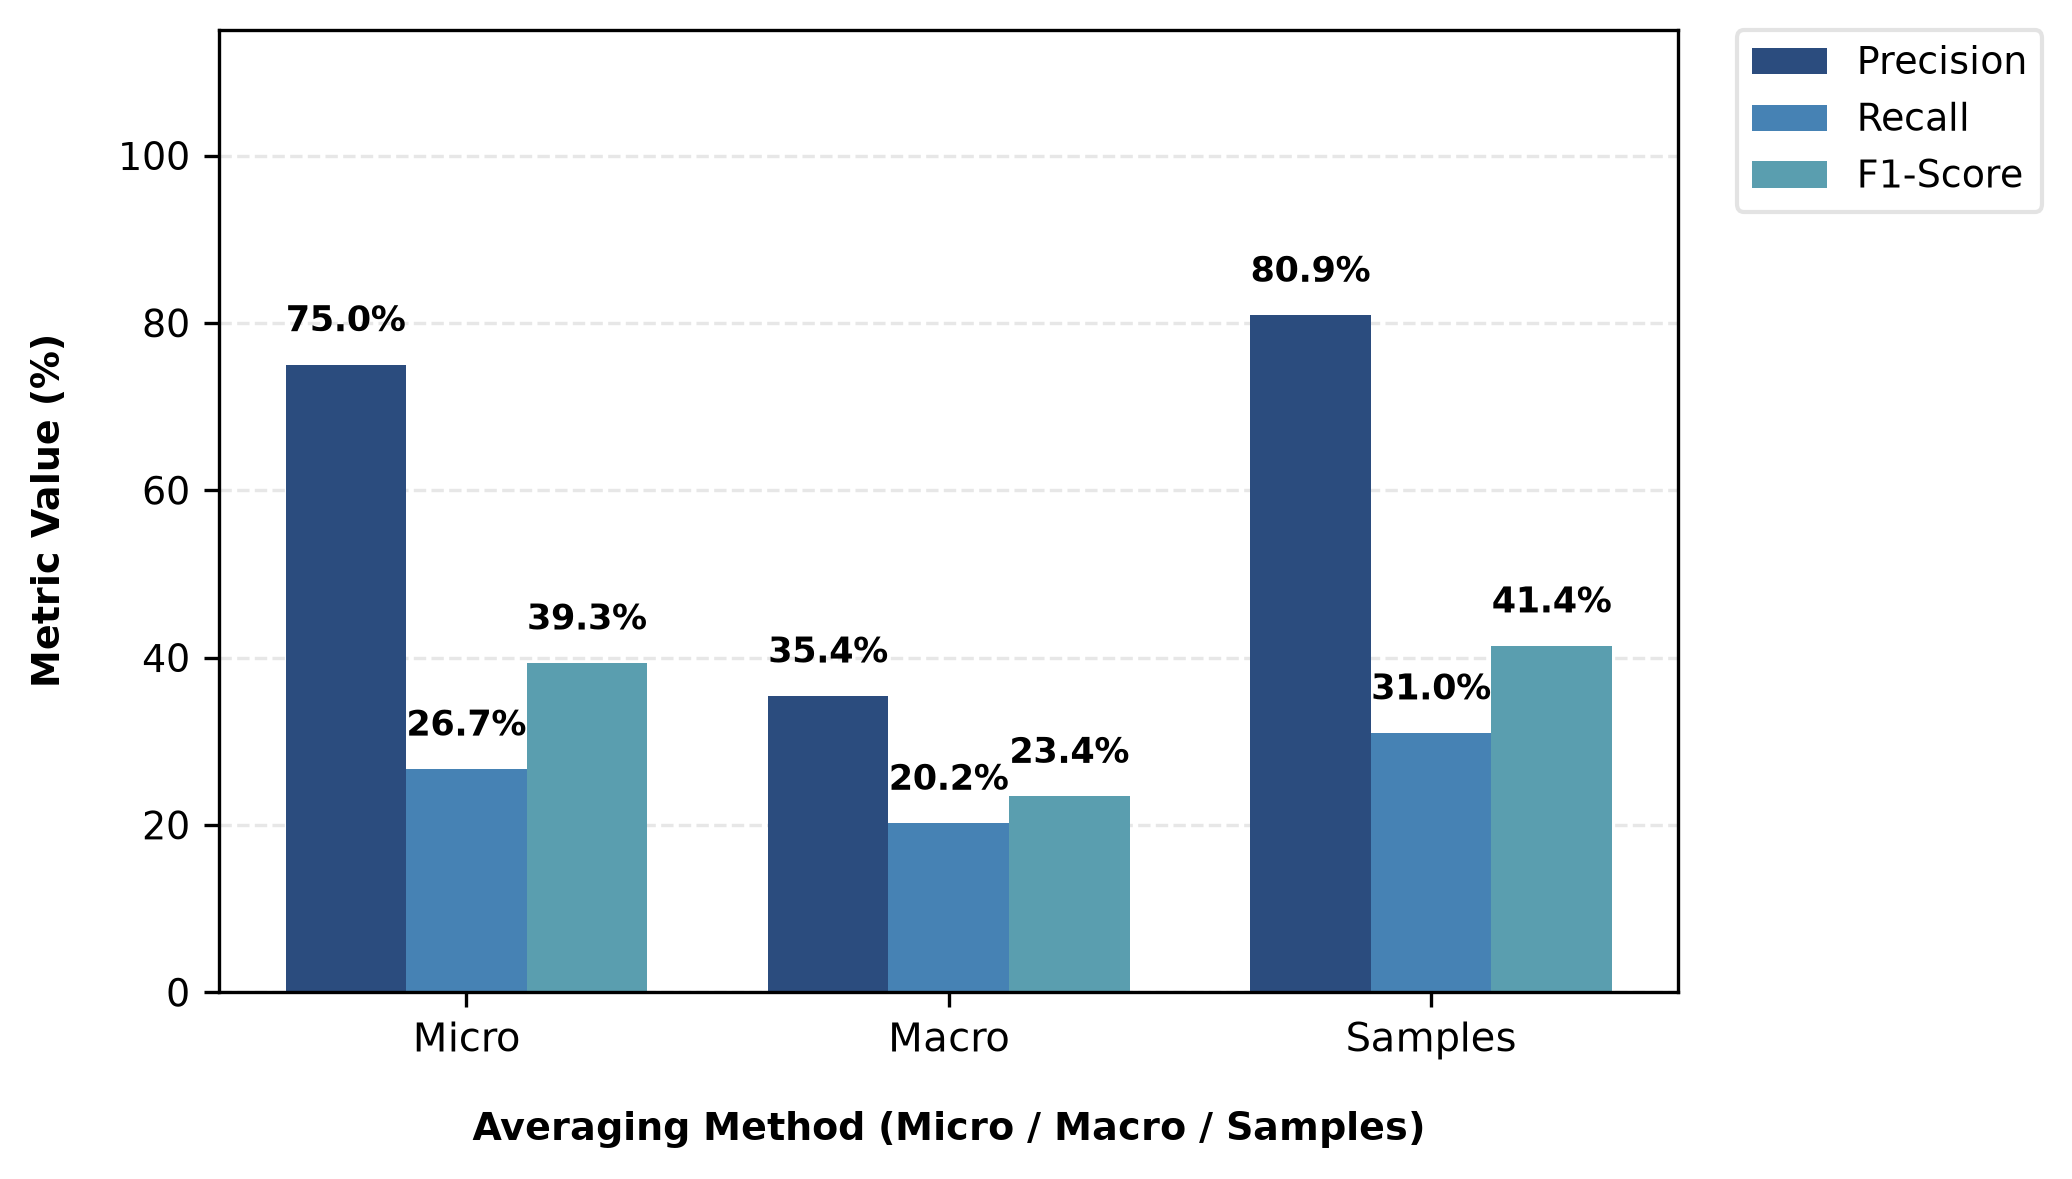

In [7]:
plot_micro_macro_samples(rows, "apk_pipeline", "../figures/figures_testset_15_runs")

In [8]:
#plot_micro_macro_samples(rows, "apk_set1", "../figures/figures_testset_15_runs")

In [9]:
#plot_micro_macro_samples(rows, "apk_set2", "../figures/figures_testset_15_runs")

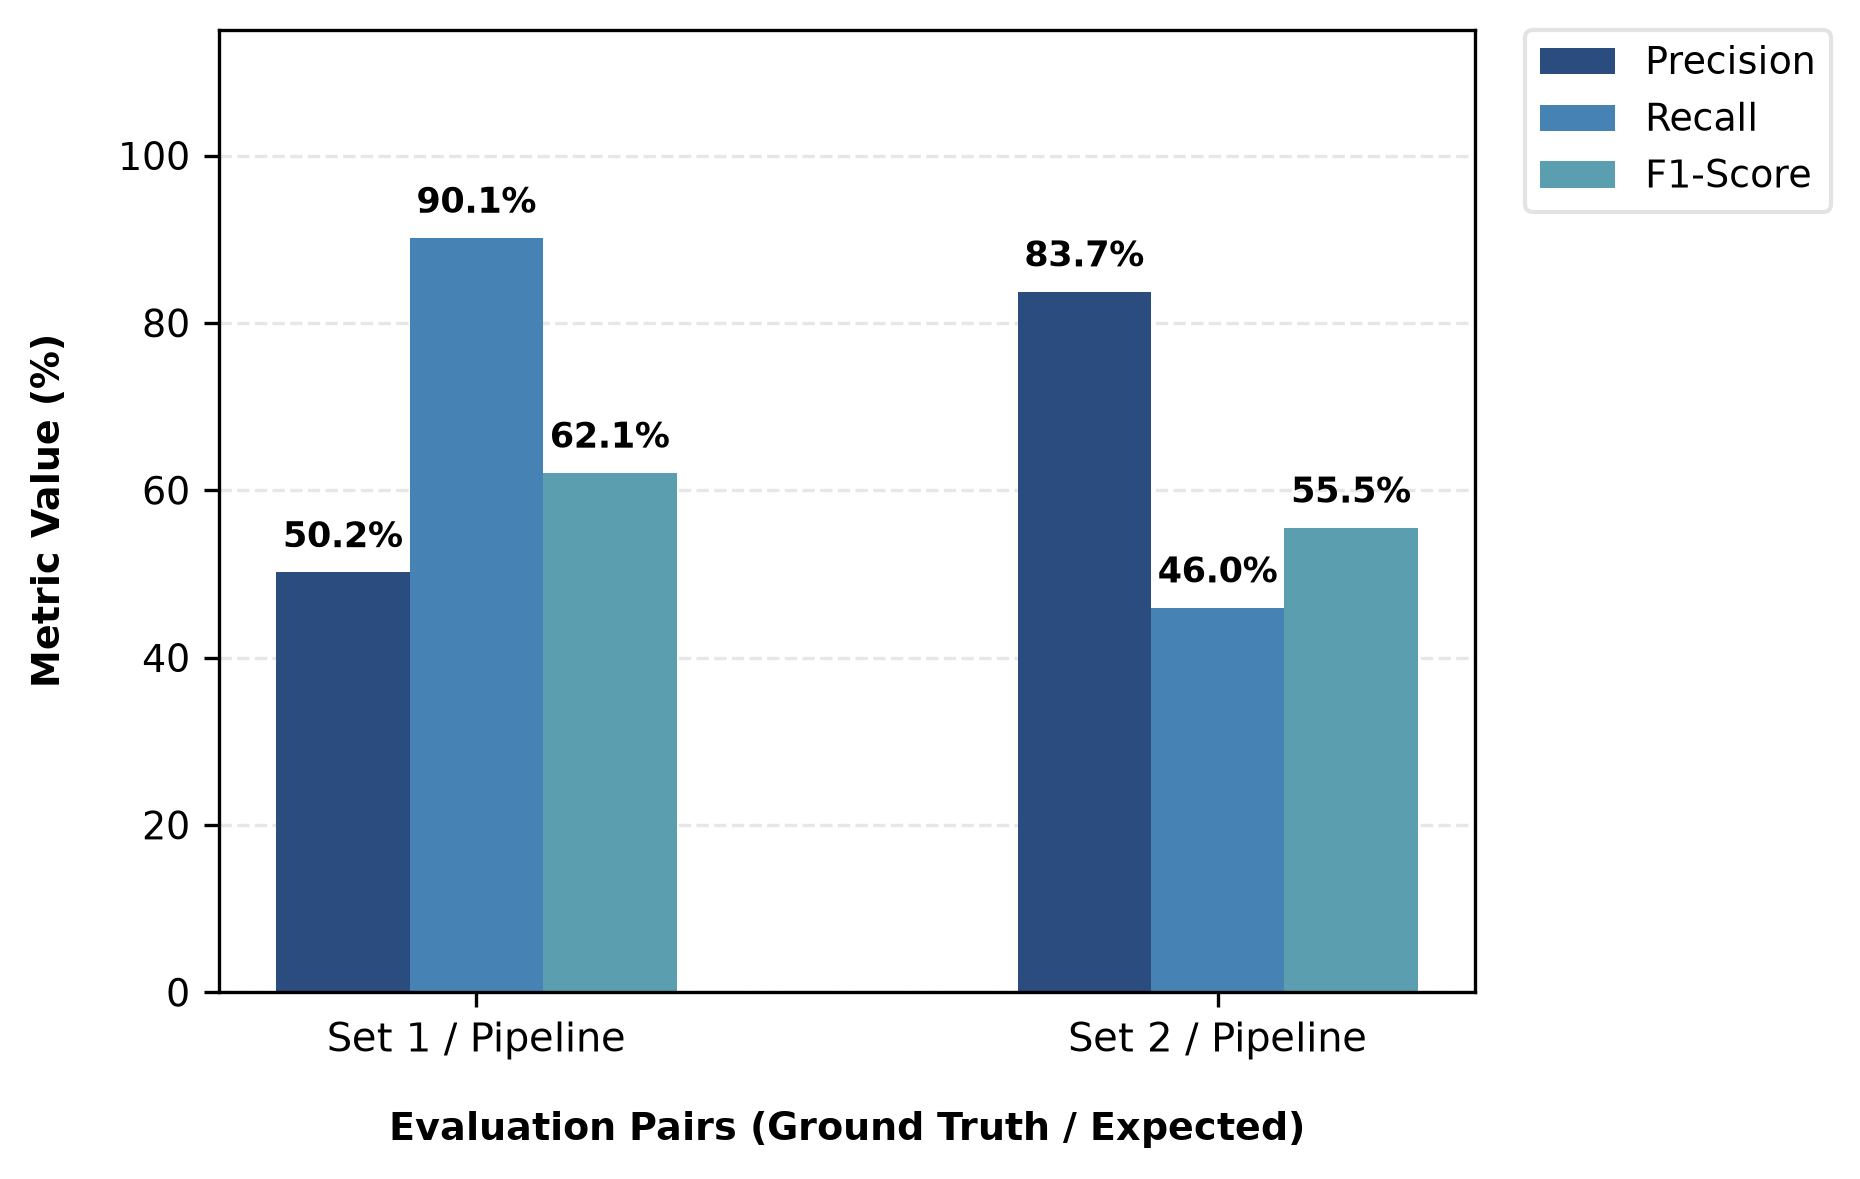

In [10]:
plot_samples_comparison(rows, ["set1_pipeline", "set2_pipeline"], "../figures/figures_testset_15_runs")

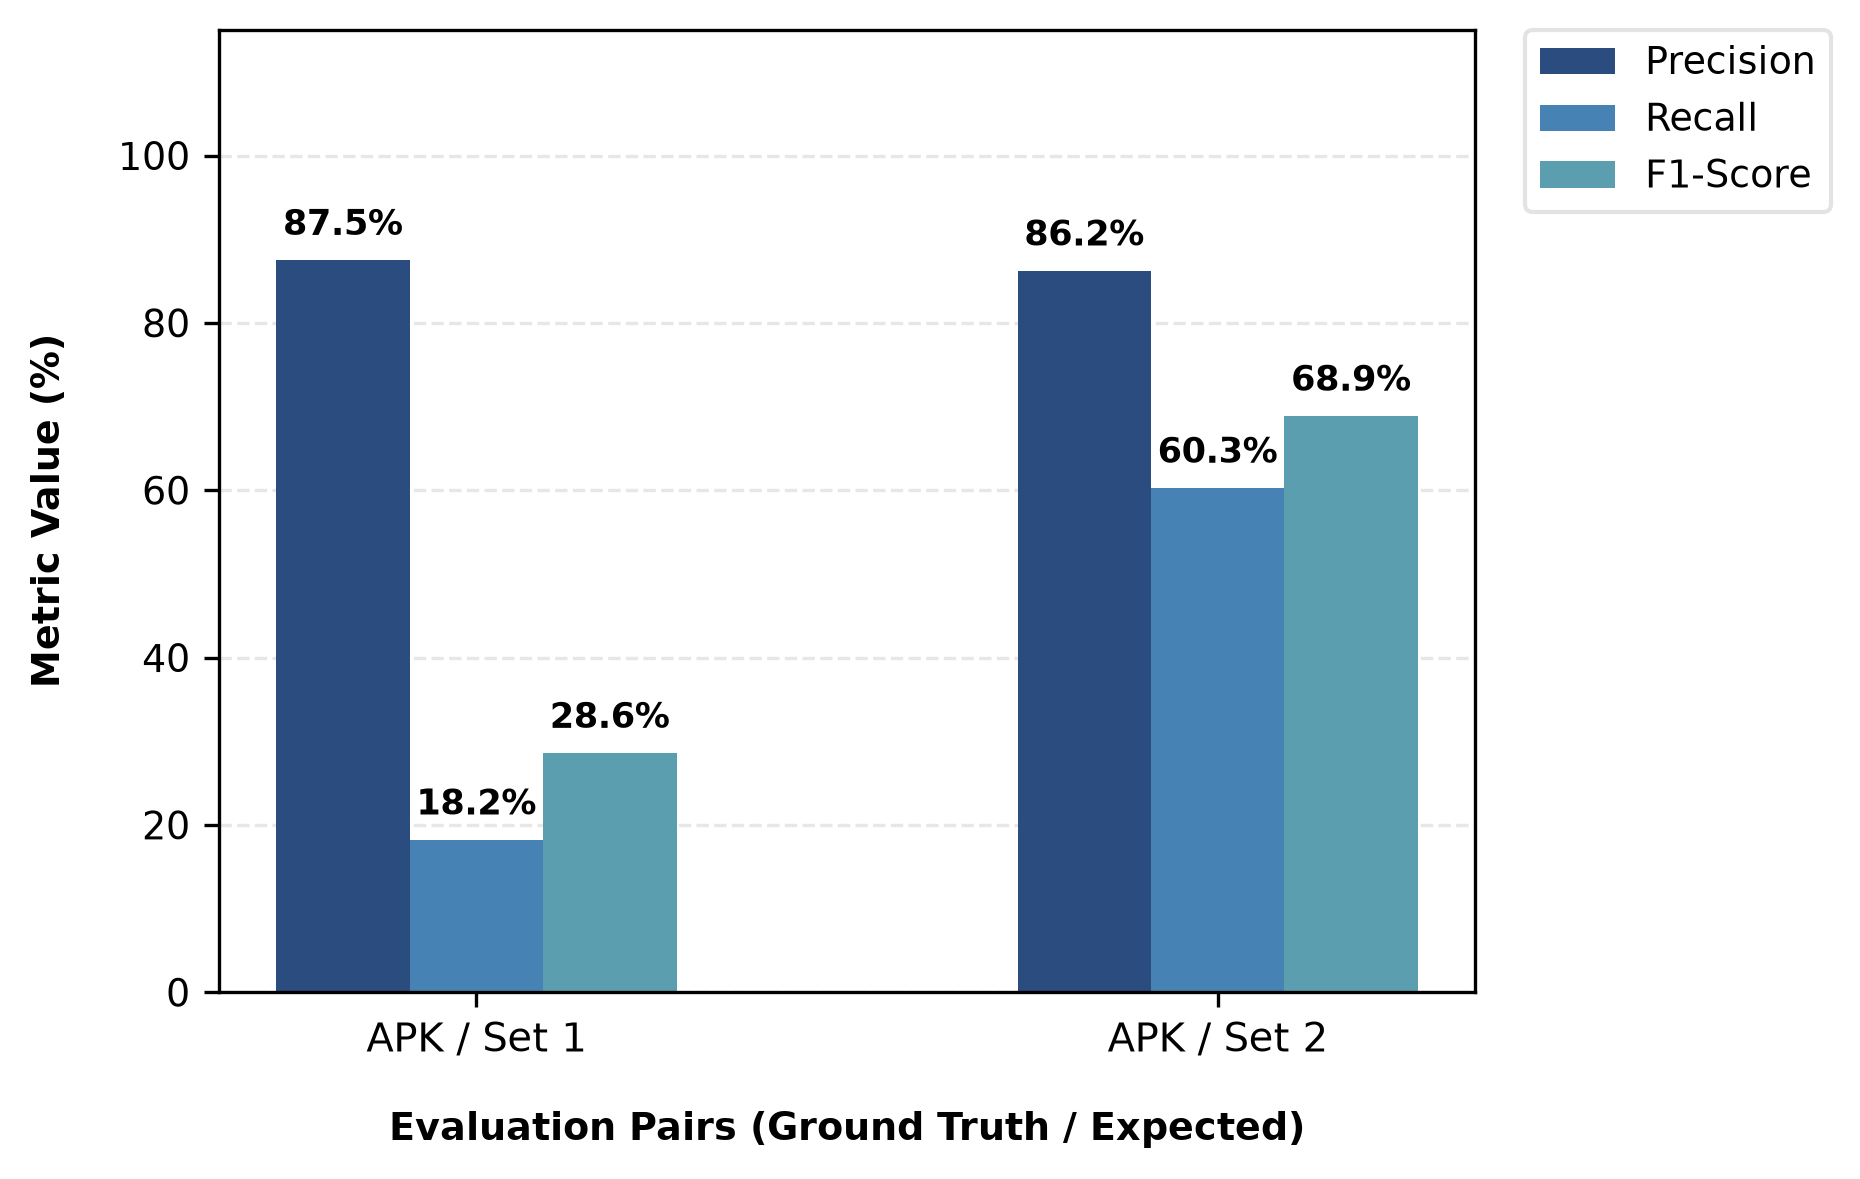

In [11]:
plot_samples_comparison(rows, ["apk_set1", "apk_set2"], "../figures/figures_testset_15_runs")

In [12]:
#plot_all_micro_macro_samples(rows,"../figures/figures_testset_15_runs")

[{'apk_permissions': ['WRITE_SYNC_SETTINGS', 'READ_MEDIA_IMAGES', 'RECORD_AUDIO', 'READ_EXTERNAL_STORAGE', 'FOREGROUND_SERVICE', 'CHANGE_WIFI_STATE', 'RECEIVE_BOOT_COMPLETED', 'ACCESS_COARSE_LOCATION', 'ACCESS_FINE_LOCATION', 'READ_CONTACTS', 'WAKE_LOCK', 'NFC', 'ACCESS_WIFI_STATE', 'SET_WALLPAPER', 'VIBRATE', 'READ_MEDIA_VIDEO', 'READ_SYNC_SETTINGS', 'ACCESS_NETWORK_STATE', 'CAMERA', 'GET_ACCOUNTS', 'WRITE_EXTERNAL_STORAGE', 'INTERNET'], 'inferred_permissions': ['ACCESS_FINE_LOCATION', 'READ_MEDIA_IMAGES', 'RECORD_AUDIO', 'CAMERA', 'READ_EXTERNAL_STORAGE', 'WRITE_EXTERNAL_STORAGE', 'MODIFY_AUDIO_SETTINGS']}, {'apk_permissions': ['NFC', 'DETECT_SCREEN_CAPTURE', 'READ_MEDIA_VIDEO', 'WAKE_LOCK', 'READ_MEDIA_VISUAL_USER_SELECTED', 'WRITE_EXTERNAL_STORAGE', 'ACCESS_WIFI_STATE', 'FOREGROUND_SERVICE', 'RECEIVE_BOOT_COMPLETED', 'ACCESS_FINE_LOCATION', 'INTERNET', 'ACCESS_COARSE_LOCATION', 'READ_MEDIA_IMAGES', 'READ_CONTACTS', 'GET_ACCOUNTS', 'READ_EXTERNAL_STORAGE', 'CAMERA', 'VIBRATE', 'ACCE

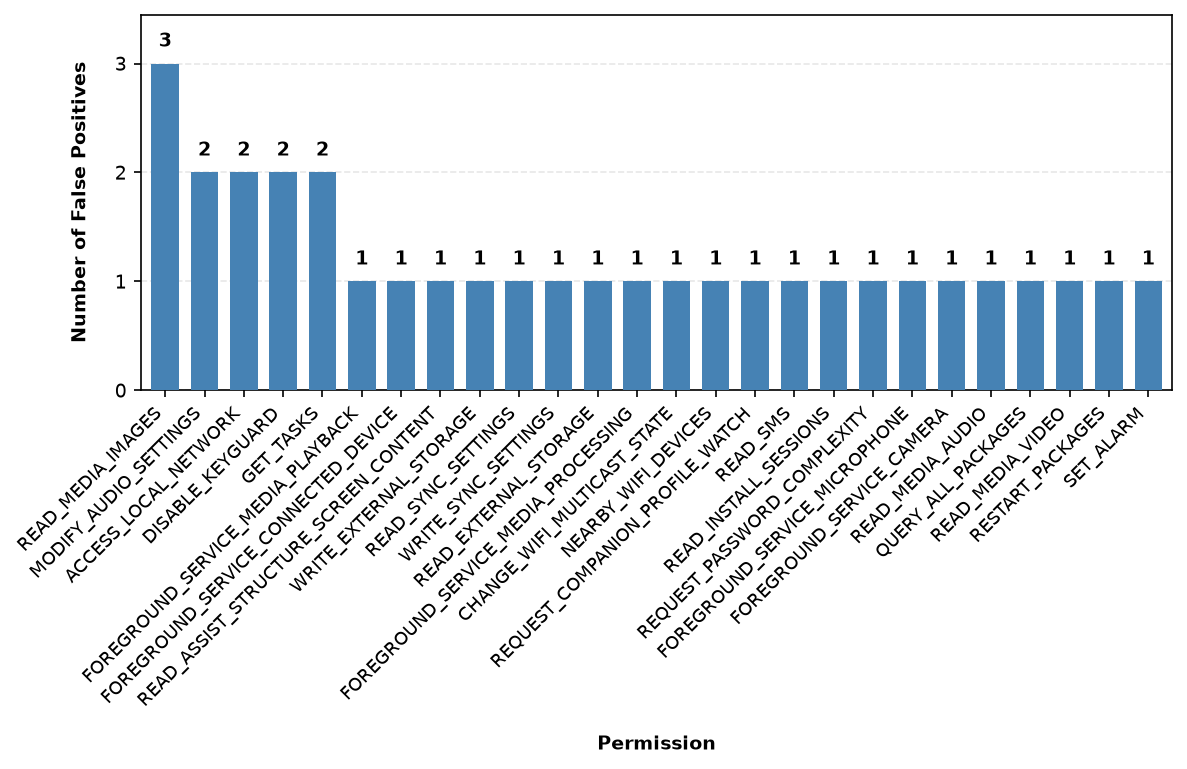

In [13]:
pair_1 = build_pairs(runs, "apk_permissions", "inferred_permissions")
print(pair_1)
fp_permissions_dicts = extract_false_positives(pair_1)
fp_permissions_counts = count_fp_permissions(fp_permissions_dicts)
plot_permission_counts_fp(fp_permissions_counts, output_dir="../figures/figures_testset_15_runs")

In [14]:
per_label_df_1 = calculate_per_label_f1(pair_1, "apk_permissions", "inferred_permissions")
# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_rows', None)
# pd.set_option('display.width', 1000)
per_label_df_1

,permission,support_truth,precision,recall,f1
0,ACCESS_NETWORK_STATE,15,1.000000,0.800000,0.888889
1,WAKE_LOCK,15,1.000000,0.066667,0.125000
2,INTERNET,15,1.000000,0.800000,0.888889
3,FOREGROUND_SERVICE,15,1.000000,0.200000,0.333333
4,READ_EXTERNAL_STORAGE,13,0.888889,0.615385,0.727273
...,...,...,...,...,...
83,READ_SMS,0,0.000000,0.000000,0.000000
84,REQUEST_COMPANION_PROFILE_WATCH,0,0.000000,0.000000,0.000000
85,SET_ALARM,0,0.000000,0.000000,0.000000
86,REQUEST_PASSWORD_COMPLEXITY,0,0.000000,0.000000,0.000000


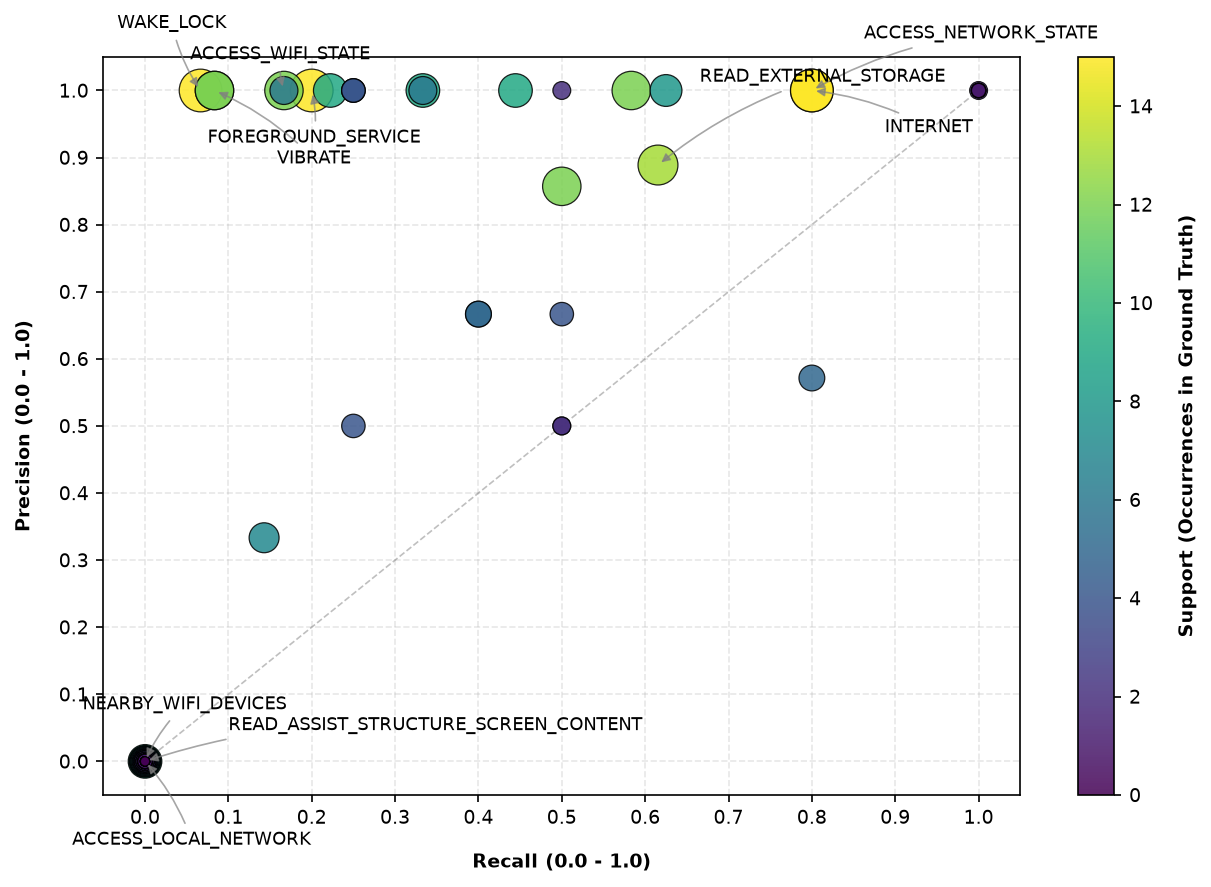

In [15]:
plot_scatter_precision_recall(per_label_df_1, top_n_labels=7, bottom_n_labels=2, save_path="../figures/figures_testset_15_runs")

In [16]:
# Load all data types collection from the runs
labels = extract_all_data_types_collection("../data/testset_results_15_runs")
df_results = calculate_per_datatype_f1(
    comparisons=labels, 
    key_truth="apk_permissions",
    key_pred="inferred_permissions"
)
print(df_results)

                    data_type  support_truth  precision    recall        f1
0   Voice or sound recordings             15   1.000000  0.733333  0.846154
1                      Videos             15   1.000000  0.666667  0.800000
2                      Photos             15   1.000000  0.666667  0.800000
3                 Music files             13   0.888889  0.615385  0.727273
4           Other audio files             13   0.888889  0.615385  0.727273
5              Files and docs             13   0.888889  0.615385  0.727273
6        Approximate location              9   1.000000  0.333333  0.500000
7                    Contacts              9   0.000000  0.000000  0.000000
8            Precise location              9   1.000000  0.333333  0.500000
9                    User IDs              8   0.000000  0.000000  0.000000
10              Email address              8   0.000000  0.000000  0.000000
11        Device or other IDs              7   0.500000  0.142857  0.222222
12          

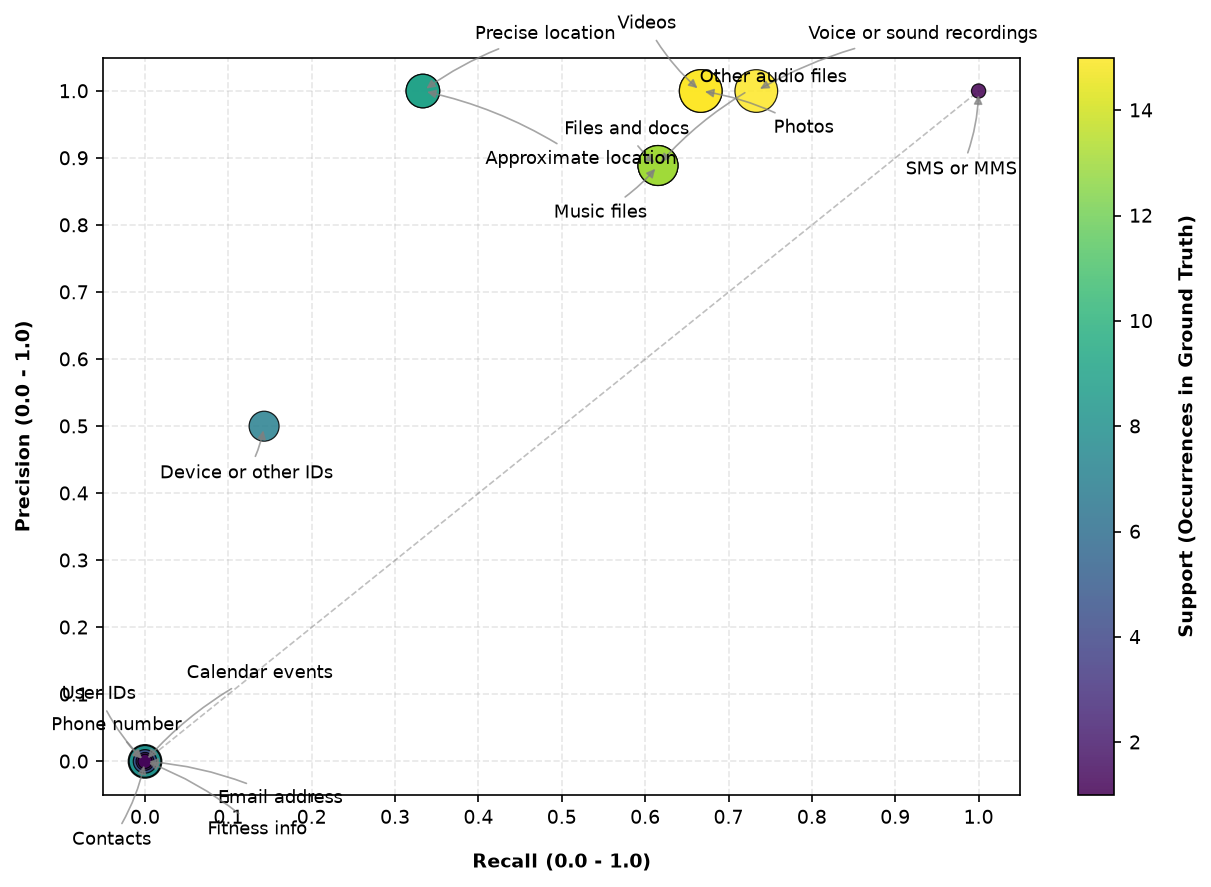

In [17]:

plot_precision_recall_by_support_data_types(df_results, top_n_labels=16, save_path="../figures/figures_testset_15_runs")
